##### Setting up the required packages

In [1]:
!python --version

Python 3.10.18


In [2]:
!pip install -r https://huggingface.co/spaces/dylanebert/LGM-mini/raw/main/requirements.txt
!pip install https://huggingface.co/spaces/dylanebert/LGM-mini/resolve/main/wheel/diff_gaussian_rasterization-0.0.0-cp310-cp310-linux_x86_64.whl --force-reinstall

  Using cached tyro-0.9.26-py3-none-any.whl.metadata (12 kB)
  Using cached diffusers-0.34.0-py3-none-any.whl.metadata (20 kB)
  Using cached einops-0.8.1-py3-none-any.whl.metadata (13 kB)
  Using cached accelerate-1.8.1-py3-none-any.whl.metadata (19 kB)
  Using cached gradio-5.35.0-py3-none-any.whl.metadata (16 kB)
  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached imageio_ffmpeg-0.6.0-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached lpips-0.1.4-py3-none-any.whl.metadata (10 kB)
  Using cached pygltflib-1.16.4-py3-none-any.whl.metadata (33 kB)
  Using cached rich-14.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached safetensors-0.5.3-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.8 kB)
  Using cached spaces-0.37.1-py3-none-any.whl.metadata (1.0 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached transformers-4.53.1-py3-none-any.whl.metadata (40 kB)
  Using cached trimesh-4.6.13-py3-none-

In [3]:
!pip install packaging

In [4]:
!pip install numpy

In [5]:
!pip install "numpy<2"

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


In [1]:
import torch
from diffusers import DiffusionPipeline

# load the multi-view diffusion pipeline
image_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/multi-view-diffusion",
    custom_pipeline="dylanebert/multi-view-diffusion",
    torch_dtype=torch.float16,
    # device_map="balanced",
    trust_remote_code=True,
).to("cuda") # the model is 4gb in gpu memory


/home/kaarl/miniconda3/envs/lgm-py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Keyword arguments {'trust_remote_code': True} are not expected by MVDreamPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 14.22it/s]
Expected types for unet: (<class 'diffusers_modules.local.dylanebert--multi-view-diffusion.3916e5568b2ee54ea8a81ce4961609158b2c464d.pipeline.MultiViewUNetModel'>,), got <class 'diffusers_modules.local.mv_unet.MultiViewUNetModel'>.


this creates a multi-view diffusion image of the object, i.e it takes in a target image and generates multiple versions of it iin different viewing angles. but how do we specify the image we want to generate multiple views of ?

In [2]:
!pip install https://huggingface.co/spaces/dylanebert/LGM-mini/resolve/main/wheel/diff_gaussian_rasterization-0.0.0-cp310-cp310-linux_x86_64.whl --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 5.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: diff-gaussian-rasterization
    Found existing installation: diff-gaussian-rasterization 0.0.0
    Uninstalling diff-gaussian-rasterization-0.0.0:
      Successfully uninstalled diff-gaussian-rasterization-0.0.0


In [ ]:
pip install git+https://github.com/graphdeco-inria/diff-gaussian-rasterization

Note: you may need to restart the kernel to use updated packages.


In [ ]:
splat_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/LGM",
    custom_pipeline="dylanebert/LGM",
    torch_dtype=torch.float16,
    # device_map="balanced",
    trust_remote_code=True,
).to("cuda")

Keyword arguments {'trust_remote_code': True} are not expected by LGMPipeline and will be ignored.
Loading pipeline components...:   0%|          | 0/1 [00:00<?, ?it/s]/home/kaarl/.cache/huggingface/modules/diffusers_modules/local/lgm.py:334: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
Loading pipeline components...: 100%|██████████| 1/1 [00:00<00:00, 20.42it/s]


#### Loading an image
we will now load the cat statue image and use it as a default image for testing due to its convenience

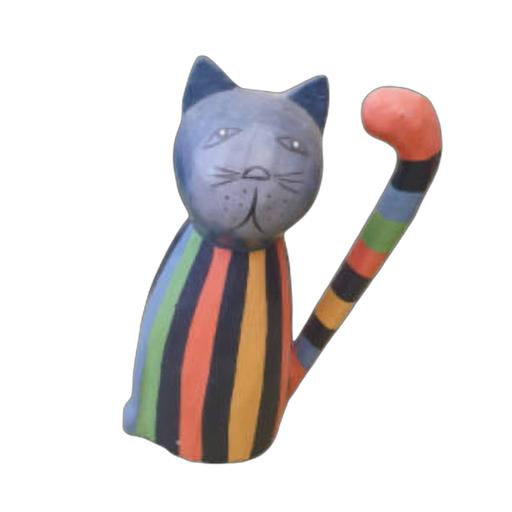

In [3]:
import requests
from PIL import Image
from io import BytesIO

image_url = "https://huggingface.co/datasets/dylanebert/3d-arena/resolve/main/inputs/images/a_cat_statue.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
image

Now we will run the image through the multiview image pipeline

In [4]:
import numpy as np

# we will conver the image to an array of floats between 0 and 1
input_image = np.array(image, dtype=np.float32) / 255.

# we will now generate the multi-view images based on the normalized image
multi_view_images = image_pipeline("", input_image, 
                                   guidance_scale=5,
                                   num_inference_steps=30, 
                                   elevation=0)

100%|██████████| 30/30 [00:02<00:00, 11.98it/s]


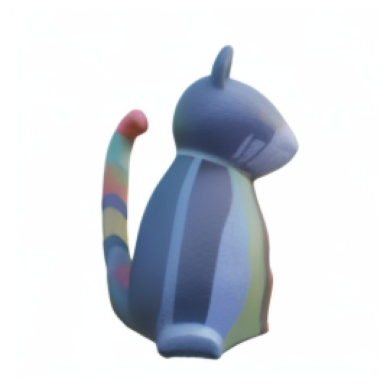

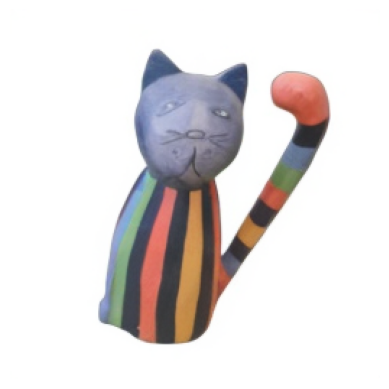

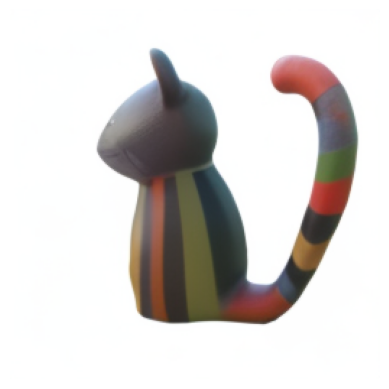

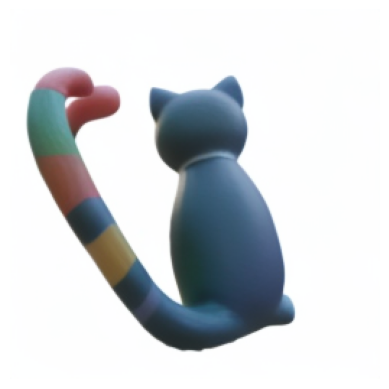

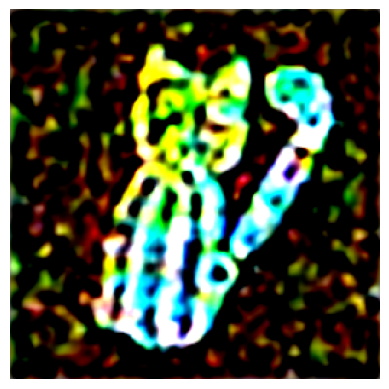

In [ ]:
import matplotlib.pyplot as plt

for i in range(len(multi_view_images)):
    plt.imshow(multi_view_images[i][0])
    plt.axis("off")
    plt.show()

# we can see that the images are generated in different viewing angles of the same object

i don't know what this 5th image is or what it is used for 

In [7]:
splat = splat_pipeline(multi_view_images)

output_path = "./cat_statue.ply"
splat_pipeline.save_ply(splat, output_path)


In [10]:
import gradio as gr

def run(image):
    input_image = image.astype("float32") / 255.0
    images = image_pipeline("", input_image, guidance_scale=5, num_inference_steps=30, elevation=0)
    splat = splat_pipeline(images)
    output_path = "./output.ply"
    splat_pipeline.save_ply(splat, output_path)
    return output_path

demo = gr.Interface(fn=run, inputs="image", outputs=gr.Model3D())
demo.launch(server_name="0.0.0.0", server_port=7861)

* Running on local URL:  http://0.0.0.0:7861
* To create a public link, set `share=True` in `launch()`.


100%|██████████| 30/30 [00:02<00:00, 12.29it/s]
